Einzigartige Werte in der Maske: [0 1]
Anzahl der Gebäude-Pixel (Wert 1): 7107


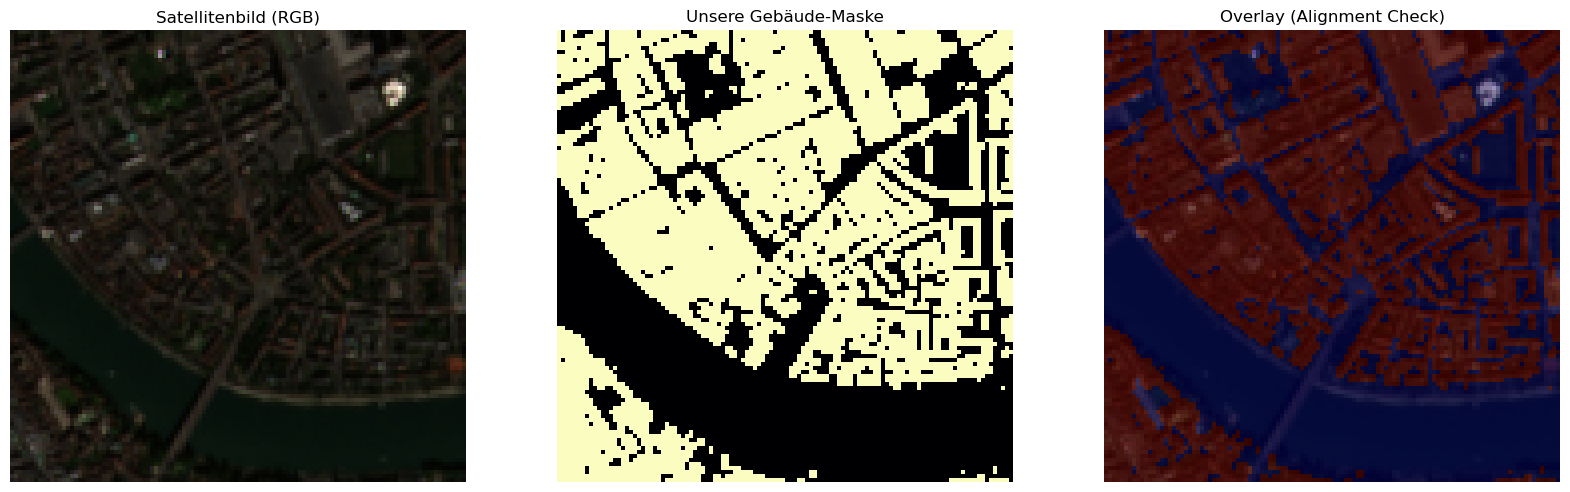

In [1]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# 1. Pfade definieren (Da das Notebook im Ordner 'notebooks' liegt, gehen wir mit '../' einen Ordner hoch)
sat_path = '../data/raw/basel_sentinel2_cropped.tif'
mask_path = '../data/processed/basel_roof_mask.tif'

# 2. Daten laden
with rasterio.open(sat_path) as sat:
    # Wir laden RGB (Band 3=Rot, 2=Grün, 1=Blau) für eine natürliche Ansicht
    # Sentinel-Daten haben oft hohe Werte, wir normieren sie für die Anzeige
    r = sat.read(3)
    g = sat.read(2)
    b = sat.read(1)
    rgb_img = np.dstack((r, g, b))
    rgb_img = (rgb_img / rgb_img.max() * 255).astype(np.uint8)

with rasterio.open(mask_path) as mask_src:
    mask = mask_src.read(1)

# 3. Der ultimative Beweis: Welche Zahlen stecken in der Matrix?
print(f"Einzigartige Werte in der Maske: {np.unique(mask)}")
print(f"Anzahl der Gebäude-Pixel (Wert 1): {np.sum(mask == 1)}")

# 4. Visualisierung (Wir zwingen matplotlib, den Wert 1 als strahlend Gelb anzuzeigen!)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

ax1.imshow(rgb_img)
ax1.set_title("Satellitenbild (RGB)")
ax1.axis('off')

ax2.imshow(mask, cmap='magma') # magma macht die 0 dunkel und die 1 extrem hell
ax2.set_title("Unsere Gebäude-Maske")
ax2.axis('off')

# Overlay: Maske über das Satellitenbild legen
ax3.imshow(rgb_img)
ax3.imshow(mask, cmap='jet', alpha=0.4) # alpha = 0.4 macht die Maske halbtransparent
ax3.set_title("Overlay (Alignment Check)")
ax3.axis('off')

plt.show()